# Preprocessing Engine & Anomaly Detection
**ShipmentSure — Predicting On-Time Delivery**

Centralized, reusable preprocessing logic (engine pattern):
- Pipeline-driven transforms modularly organized
- IsolationForest-style anomaly detection to flag rare shipment behavior

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import IsolationForest
from sklearn.base import BaseEstimator, TransformerMixin

sns.set_theme(style="whitegrid")
print("Libraries loaded.")

Libraries loaded.


In [10]:
df = pd.read_csv('../data/Train.csv')
if 'ID' in df.columns:
    df = df.drop('ID', axis=1)
print(f"Shape: {df.shape}")

Shape: (1000, 11)


In [11]:
# Preprocessing Engine — modular class with fit/transform
class PreprocessingEngine(BaseEstimator, TransformerMixin):
    """Centralized preprocessing engine combining imputation, scaling, and encoding."""
    
    def __init__(self, num_cols, cat_cols):
        self.num_cols = num_cols
        self.cat_cols = cat_cols
        self._build_pipeline()
    
    def _build_pipeline(self):
        num_pipe = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ])
        cat_pipe = Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ])
        self.preprocessor_ = ColumnTransformer([
            ('num', num_pipe, self.num_cols),
            ('cat', cat_pipe, self.cat_cols)
        ])
    
    def fit(self, X, y=None):
        self.preprocessor_.fit(X)
        return self
    
    def transform(self, X):
        return self.preprocessor_.transform(X)

In [12]:
# Use the engine
target_col = 'Reached.on.Time_Y.N'
X = df.drop(target_col, axis=1)
y = df[target_col]

num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include='object').columns.tolist()

engine = PreprocessingEngine(num_cols=num_cols, cat_cols=cat_cols)
engine.fit(X)
X_processed = engine.transform(X)
print(f"Preprocessed shape: {X_processed.shape}")

Preprocessed shape: (1000, 19)


In [13]:
# Anomaly Detection with IsolationForest
iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
X_num_only = df[num_cols].copy()

anomaly_pred = iso_forest.fit_predict(X_num_only)
anomaly_scores = iso_forest.decision_function(X_num_only)

df['anomaly_label'] = anomaly_pred   # -1 = anomaly, 1 = normal
df['anomaly_score'] = anomaly_scores

n_anomalies = (df['anomaly_label'] == -1).sum()
print(f"Detected anomalies: {n_anomalies} ({n_anomalies/len(df)*100:.1f}%)")

Detected anomalies: 50 (5.0%)


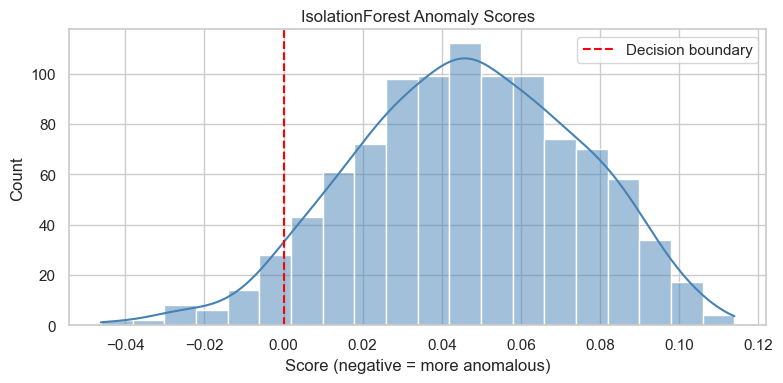

In [14]:
# Visualize anomaly scores
plt.figure(figsize=(8, 4))
sns.histplot(df['anomaly_score'], kde=True, color='steelblue')
plt.axvline(0, color='red', linestyle='--', label='Decision boundary')
plt.title('IsolationForest Anomaly Scores')
plt.xlabel('Score (negative = more anomalous)')
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
# Anomaly profile — what makes anomalous shipments different?
anomaly_profile = df.groupby('anomaly_label')[num_cols].mean().round(3)
anomaly_profile.index = ['Anomaly (-1)', 'Normal (1)']
print("Mean features: Anomaly vs Normal shipments:")
anomaly_profile

Mean features: Anomaly vs Normal shipments:


,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms
Anomaly (-1),5.380,2.840,189.860,6.080,29.700,3116.940
Normal (1),4.478,2.988,200.866,5.979,32.107,3521.648


In [16]:
# Remove anomalies for cleaner training data
df_clean = df[df['anomaly_label'] == 1].drop(['anomaly_label', 'anomaly_score'], axis=1)
print(f"Dataset size after anomaly removal: {df_clean.shape} (removed {len(df) - len(df_clean)} rows)")

Dataset size after anomaly removal: (950, 11) (removed 50 rows)
